# ✂️ Notebook 04 — Outlier Handling IQR Clipping

---

<div style="background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%); padding: 24px 28px; border-radius: 16px; margin: 12px 0; border: 1px solid #e94560;">
<h2 style="color: #e94560; margin: 0 0 8px 0; font-size: 1.4em;">✂️ Outlier Handling — IQR Clipping</h2>
<h3 style="color: #a8dadc; margin: 0 0 16px 0; font-weight: 400; font-size: 1.05em;">Fase A — Fondasi Data dan Eksperimen</h3>
<hr style="border: none; border-top: 1px solid #444; margin: 12px 0;">
<table style="color: #ccc; font-size: 0.9em; border-collapse: collapse; width: 100%;">
<tr><td style="padding: 4px 16px 4px 0; white-space:nowrap;">📍 Studi Kasus</td><td><strong style="color: #fff;">PT. XYZ Banjarmasin, Kalimantan Selatan</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">🎓 Mata Kuliah</td><td><strong style="color: #fff;">Tugas Akhir — ES234733</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">🏛 Institusi</td><td><strong style="color: #fff;">Departemen Sistem Informasi, FTEIC — ITS Surabaya</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">👤 Penulis</td><td><strong style="color: #fff;">Muhammad Iqbal Baiduri Yamani — NRP 5026221103</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">🧑‍🏫 Pembimbing</td><td><strong style="color: #fff;">Edwin Riksakomara, S.Kom., M.T.</strong></td></tr>
<tr><td style="padding: 4px 16px 4px 0;">📅 Tahun</td><td><strong style="color: #fff;">2025</strong></td></tr>
</table>
</div>

## 📌 Tujuan Notebook Ini

Notebook 04 melakukan **penanganan outlier dengan metode IQR Clipping** terhadap kolom `Grand Total`. Outlier yang terdeteksi pada EDA (NB03) tidak dihapus — melainkan di-*clip* ke batas IQR agar tidak merusak pola temporal data, sesuai desain pipeline penelitian.

| # | Tahapan | Keterangan |
|---|---------|------------|
| 1 | **Import & Setup** | Muat library, seed `GLOBAL_SEED = 42`, dan PATHS |
| 2 | **Load Data** | Reload `df_sorted` dari `.xlsx` |
| 3 | **Hitung Batas IQR** | Q1, Q3, IQR, `lower_fence`, `upper_fence` |
| 4 | **Terapkan IQR Clipping** | Clip nilai ke `[lower_fence, upper_fence]` → `df_clipped` |
| 5 | **Before-After Analysis** | Tabel perbandingan statistik & plot visual |
| 6 | **Simpan Artefak** | `logs/outlier_handling.json` + 3 figur PNG |
| 7 | **Checklist** | Verifikasi semua item Pipeline.md Gate 2 terpenuhi |

---

### 🔬 Konteks Penanganan Outlier

**Input:** `df_sorted` (364 × 3) — output audit Notebook 02, divalidasi EDA Notebook 03.

**Alur Proses di Notebook Ini:**

```mermaid
flowchart LR
    A["📊 df_sorted: 364×3"] --> B["Hitung Q1, Q3, IQR"]
    B --> C["Tentukan lower_fence & upper_fence"]
    C --> D["IQR Clipping: clip ke batas"]
    D --> E["df_clipped: 364×3"]
    E --> F["Before-After Analysis"]
    F --> G["💾 outlier_handling.json"]
    G --> H["✅ Outlier Handling Selesai"]
    H --> I["➡️ Notebook 05"]
```

| Aspek | Detail |
|-------|--------|
| **Metode** | IQR Clipping (Winsorization) — nilai di luar batas digeser ke batas |
| **Batas Bawah** | `lower_fence = Q1 − 1.5 × IQR` |
| **Batas Atas** | `upper_fence = Q3 + 1.5 × IQR` |
| **Outlier NB03** | 6 minggu terdeteksi melewati batas IQR |
| **Output** | `df_clipped` (364×3), `logs/outlier_handling.json`, 3 figur PNG |

## ⚙️ 1. Import Library & Setup

In [1]:
# ── Import Library & Setup ────────────────────────────────────
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# ── Path Konfigurasi ──────────────────────────────────────────
ROOT_DIR   = Path(".").resolve().parent
EXCEL_FILE = "Dataset_Raw_Top 1 Sales 2019 - 2025.xlsx"
EXCEL_PATH = ROOT_DIR / "data" / EXCEL_FILE

PATHS = {
    "root"        : ROOT_DIR,
    "data"        : ROOT_DIR / "data",
    "logs"        : ROOT_DIR / "logs",
    "outputs"     : ROOT_DIR / "outputs",
    "figures"     : ROOT_DIR / "outputs" / "figures",
    "models"      : ROOT_DIR / "outputs" / "models",
    "metrics"     : ROOT_DIR / "outputs" / "metrics",
    "splits"      : ROOT_DIR / "outputs" / "splits",
    "cv_folds"    : ROOT_DIR / "outputs" / "cv_folds",
    "checkpoints" : ROOT_DIR / "outputs" / "checkpoints",
    "reports"     : ROOT_DIR / "outputs" / "reports",
    "assets"      : ROOT_DIR / "outputs" / "assets",
    "notebooks"   : ROOT_DIR / "notebook",
}

for p in PATHS.values():
    if isinstance(p, Path):
        p.mkdir(parents=True, exist_ok=True)

# ── Matplotlib Style ──────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor"  : "#1a1a2e",
    "axes.facecolor"    : "#16213e",
    "axes.edgecolor"    : "#444",
    "axes.labelcolor"   : "#ccc",
    "xtick.color"       : "#aaa",
    "ytick.color"       : "#aaa",
    "text.color"        : "#ddd",
    "grid.color"        : "#2a2a4a",
    "grid.linestyle"    : "--",
    "grid.linewidth"    : 0.5,
    "axes.grid"         : True,
    "font.family"       : "DejaVu Sans",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
})

print("=" * 60)
print("  SETUP — NOTEBOOK 04")
print("=" * 60)
print(f"")
print(f"  GLOBAL_SEED  : {GLOBAL_SEED}")
print(f"  ROOT_DIR     : {ROOT_DIR}")
print(f"  EXCEL_PATH   : {EXCEL_PATH}")
print(f"  NumPy        : {np.__version__}")
print(f"  Pandas       : {pd.__version__}")
print(f"  Matplotlib   : {matplotlib.__version__}")
print(f"  Seaborn      : {sns.__version__}")
print(f"")
print("  ✅ Setup selesai. Siap Outlier Handling IQR Clipping.")
print("=" * 60)

  SETUP — NOTEBOOK 04

  GLOBAL_SEED  : 42
  ROOT_DIR     : C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting
  EXCEL_PATH   : C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\data\Dataset_Raw_Top 1 Sales 2019 - 2025.xlsx
  NumPy        : 2.4.4
  Pandas       : 3.0.2
  Matplotlib   : 3.10.9
  Seaborn      : 0.13.2

  ✅ Setup selesai. Siap Outlier Handling IQR Clipping.


## 📂 2. Load Data

In [2]:
# ── Load Data ─────────────────────────────────────────────────
df_raw = pd.read_excel(
    EXCEL_PATH,
    sheet_name="Target_Product_Weekly",
    engine="openpyxl"
)
df_sorted = df_raw.sort_values(["Year", "Week"]).reset_index(drop=True)

print("=" * 60)
print("  LOAD DATA — NOTEBOOK 04")
print("=" * 60)
print(f"  df_sorted shape : {df_sorted.shape}")
print(f"  Kolom           : {list(df_sorted.columns)}")
print(f"  Tipe data:")
for col, dtype in df_sorted.dtypes.items():
    print(f"    {col}: {dtype}")
print("=" * 60)

  LOAD DATA — NOTEBOOK 04
  df_sorted shape : (364, 3)
  Kolom           : ['Year', 'Week', 'Grand Total']
  Tipe data:
    Year: int64
    Week: int64
    Grand Total: int64


## 📐 3. Hitung Batas IQR

In [3]:
# ── Hitung Batas IQR ─────────────────────────────────────────
series = df_sorted["Grand Total"]

Q1 = series.quantile(0.25)
Q3 = series.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outlier_mask   = (series < lower_fence) | (series > upper_fence)
n_outliers     = outlier_mask.sum()
outlier_indices = df_sorted[outlier_mask].index.tolist()

print("=" * 60)
print("  BATAS IQR — Grand Total (Sebelum Clipping)")
print("=" * 60)
print(f"  Q1 (25%)         : {Q1:,.2f}")
print(f"  Q3 (75%)         : {Q3:,.2f}")
print(f"  IQR              : {IQR:,.2f}")
print(f"  Lower Fence      : {lower_fence:,.2f}")
print(f"  Upper Fence      : {upper_fence:,.2f}")
print(f"  Outlier ditemukan: {n_outliers} data point")
print()
if n_outliers > 0:
    print("  Detail outlier:")
    for idx in outlier_indices:
        row = df_sorted.loc[idx]
        side = "ATAS" if row["Grand Total"] > upper_fence else "BAWAH"
        print(f"    Idx={idx:3d}  Year={int(row['Year'])}  Week={int(row['Week']):2d}  ",
              f"Grand Total={int(row['Grand Total']):,}  [{side}]")
print("=" * 60)

  BATAS IQR — Grand Total (Sebelum Clipping)
  Q1 (25%)         : 40,078.75
  Q3 (75%)         : 65,113.50
  IQR              : 25,034.75
  Lower Fence      : 2,526.62
  Upper Fence      : 102,665.62
  Outlier ditemukan: 6 data point

  Detail outlier:
    Idx= 22  Year=2019  Week=23   Grand Total=1,305  [BAWAH]
    Idx=103  Year=2020  Week=52   Grand Total=108,856  [ATAS]
    Idx=168  Year=2022  Week=13   Grand Total=111,217  [ATAS]
    Idx=189  Year=2022  Week=34   Grand Total=107,818  [ATAS]
    Idx=194  Year=2022  Week=39   Grand Total=112,040  [ATAS]
    Idx=205  Year=2022  Week=50   Grand Total=104,036  [ATAS]


## ✂️ 4. Terapkan IQR Clipping

In [4]:
# ── IQR Clipping ─────────────────────────────────────────────
df_clipped = df_sorted.copy()
df_clipped["Grand Total"] = df_clipped["Grand Total"].clip(
    lower=lower_fence,
    upper=upper_fence
)

# Verifikasi tidak ada outlier tersisa
remaining = ((df_clipped["Grand Total"] < lower_fence) |
             (df_clipped["Grand Total"] > upper_fence)).sum()

print("=" * 60)
print("  IQR CLIPPING — Hasil")
print("=" * 60)
print(f"  Shape sebelum   : {df_sorted.shape}")
print(f"  Shape sesudah   : {df_clipped.shape}")
print(f"  Outlier di-clip : {n_outliers} data point")
print(f"  Outlier tersisa : {remaining}")
print(f"  Min sebelum     : {df_sorted['Grand Total'].min():,}")
print(f"  Min sesudah     : {df_clipped['Grand Total'].min():,.2f}")
print(f"  Max sebelum     : {df_sorted['Grand Total'].max():,}")
print(f"  Max sesudah     : {df_clipped['Grand Total'].max():,.2f}")
print("=" * 60)

  IQR CLIPPING — Hasil
  Shape sebelum   : (364, 3)
  Shape sesudah   : (364, 3)
  Outlier di-clip : 6 data point
  Outlier tersisa : 0
  Min sebelum     : 1,305
  Min sesudah     : 2,526.62
  Max sebelum     : 112,040
  Max sesudah     : 102,665.62


## 📊 5. Before-After Analysis

In [9]:

# ── Before-After: Tabel Statistik ────────────────────────────
def desc_stats(s):
    return {
        "mean"     : round(float(s.mean()), 4),
        "median"   : round(float(s.median()), 4),
        "std"      : round(float(s.std()), 4),
        "min"      : round(float(s.min()), 4),
        "max"      : round(float(s.max()), 4),
        "skewness" : round(float(stats.skew(s)), 4),
        "kurtosis" : round(float(stats.kurtosis(s)), 4),
    }

stats_before = desc_stats(df_sorted["Grand Total"])
stats_after  = desc_stats(df_clipped["Grand Total"])

print("=" * 66)
print("  BEFORE-AFTER STATISTIK — Grand Total")
print("=" * 66)
print(f"  {'Metrik':<15} {'Sebelum':>18} {'Sesudah':>18} {'Δ':>12}")
print("-" * 66)
for key in stats_before:
    b = stats_before[key]
    a = stats_after[key]
    delta = round(a - b, 4)
    print(f"  {key:<15} {b:>18,.4f} {a:>18,.4f} {delta:>+12,.4f}")
print("=" * 66)


  BEFORE-AFTER STATISTIK — Grand Total
  Metrik                     Sebelum            Sesudah            Δ
------------------------------------------------------------------
  mean                   53,322.8956        53,242.0790     -80.8166
  median                 51,108.5000        51,108.5000      +0.0000
  std                    18,426.2445        18,171.8741    -254.3704
  min                     1,305.0000         2,526.6250  +1,221.6250
  max                   112,040.0000       102,665.6250  -9,374.3750
  skewness                    0.4699             0.3885      -0.0814
  kurtosis                    0.4145             0.1329      -0.2816


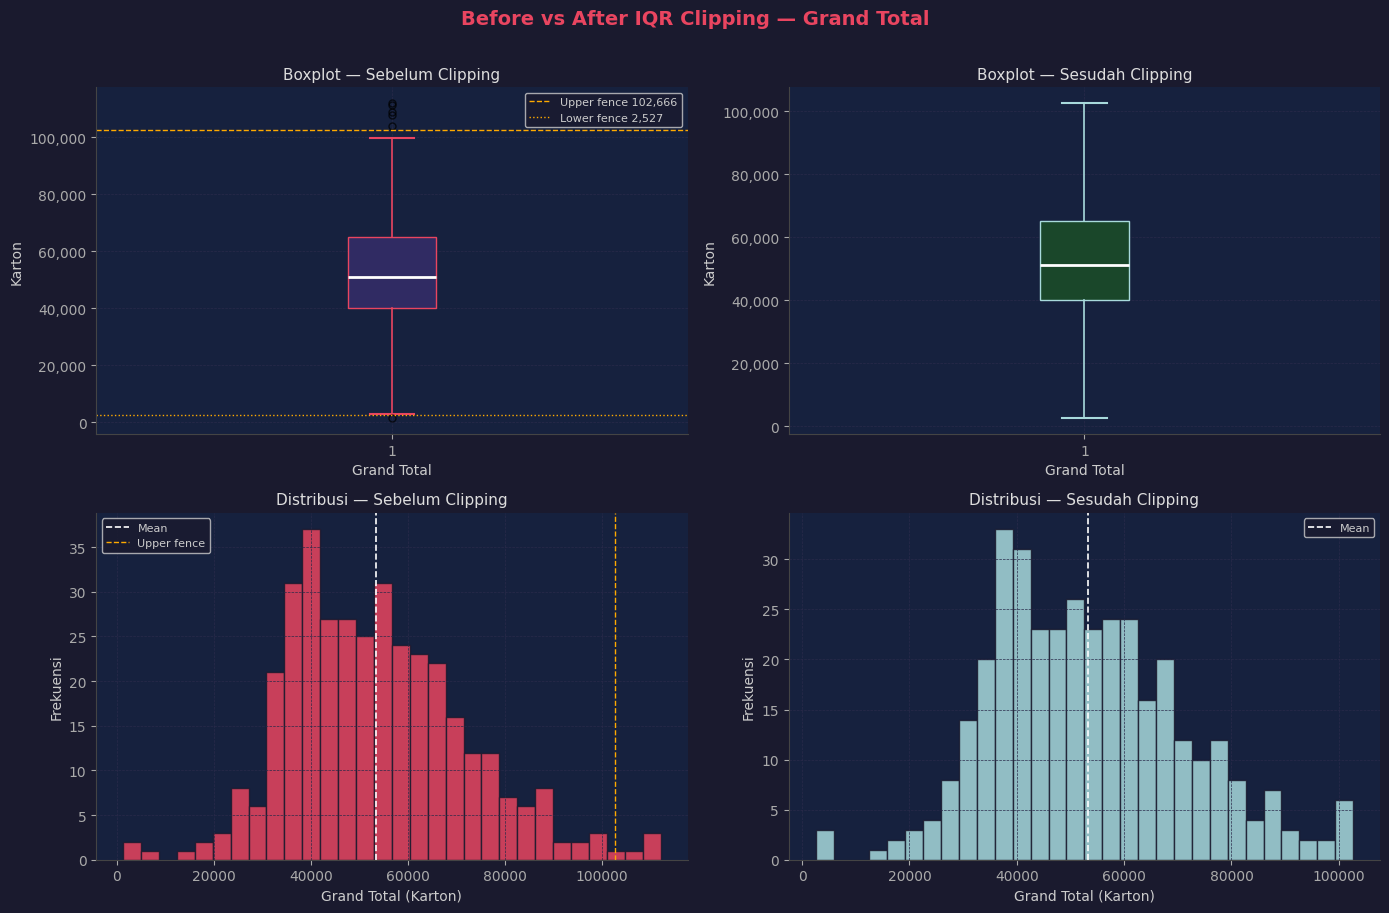

✅ Tersimpan: C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\outputs\figures\nb04_before_after_boxplot_dist.png


In [10]:
# ── Before-After: Boxplot & Distribusi ───────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9),
                         facecolor="#1a1a2e")
fig.suptitle("Before vs After IQR Clipping — Grand Total",
             fontsize=14, color="#e94560", fontweight="bold", y=1.01)

ACCENT  = "#e94560"
ACCENT2 = "#a8dadc"

def style_ax(ax):
    ax.set_facecolor("#16213e")
    ax.tick_params(colors="#aaa")
    ax.xaxis.label.set_color("#ccc")
    ax.yaxis.label.set_color("#ccc")
    ax.title.set_color("#ddd")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# ── Panel 1: Boxplot Before ──────────────────────────────────
ax = axes[0, 0]
bp1 = ax.boxplot(df_sorted["Grand Total"],
                 vert=True, patch_artist=True,
                 medianprops=dict(color="#fff", linewidth=2),
                 boxprops=dict(facecolor="#302b63", color=ACCENT),
                 whiskerprops=dict(color=ACCENT, linewidth=1.2),
                 capprops=dict(color=ACCENT, linewidth=1.5),
                 flierprops=dict(marker="o", color=ACCENT, markersize=5, alpha=0.7))
ax.axhline(upper_fence, color="#ffaa00", linestyle="--", linewidth=1,
           label=f"Upper fence {upper_fence:,.0f}")
ax.axhline(lower_fence, color="#ffaa00", linestyle=":", linewidth=1,
           label=f"Lower fence {lower_fence:,.0f}")
ax.set_title("Boxplot — Sebelum Clipping", fontsize=11)
ax.set_xlabel("Grand Total")
ax.set_ylabel("Karton")
ax.legend(fontsize=8, facecolor="#1a1a2e", labelcolor="#ccc")
style_ax(ax)

# ── Panel 2: Boxplot After ───────────────────────────────────
ax = axes[0, 1]
bp2 = ax.boxplot(df_clipped["Grand Total"],
                 vert=True, patch_artist=True,
                 medianprops=dict(color="#fff", linewidth=2),
                 boxprops=dict(facecolor="#1a472a", color=ACCENT2),
                 whiskerprops=dict(color=ACCENT2, linewidth=1.2),
                 capprops=dict(color=ACCENT2, linewidth=1.5),
                 flierprops=dict(marker="o", color=ACCENT2, markersize=5, alpha=0.7))
ax.set_title("Boxplot — Sesudah Clipping", fontsize=11)
ax.set_xlabel("Grand Total")
ax.set_ylabel("Karton")
style_ax(ax)

# ── Panel 3: Distribusi Before ───────────────────────────────
ax = axes[1, 0]
ax.hist(df_sorted["Grand Total"], bins=30,
        color=ACCENT, edgecolor="#1a1a2e", alpha=0.85)
ax.axvline(df_sorted["Grand Total"].mean(), color="#fff",
           linestyle="--", linewidth=1.2, label="Mean")
ax.axvline(upper_fence, color="#ffaa00", linestyle="--",
           linewidth=1, label=f"Upper fence")
ax.set_title("Distribusi — Sebelum Clipping", fontsize=11)
ax.set_xlabel("Grand Total (Karton)")
ax.set_ylabel("Frekuensi")
ax.legend(fontsize=8, facecolor="#1a1a2e", labelcolor="#ccc")
style_ax(ax)

# ── Panel 4: Distribusi After ────────────────────────────────
ax = axes[1, 1]
ax.hist(df_clipped["Grand Total"], bins=30,
        color=ACCENT2, edgecolor="#1a1a2e", alpha=0.85)
ax.axvline(df_clipped["Grand Total"].mean(), color="#fff",
           linestyle="--", linewidth=1.2, label="Mean")
ax.set_title("Distribusi — Sesudah Clipping", fontsize=11)
ax.set_xlabel("Grand Total (Karton)")
ax.set_ylabel("Frekuensi")
ax.legend(fontsize=8, facecolor="#1a1a2e", labelcolor="#ccc")
style_ax(ax)

plt.tight_layout()

fig_path = PATHS["figures"] / "nb04_before_after_boxplot_dist.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Tersimpan: {fig_path}")

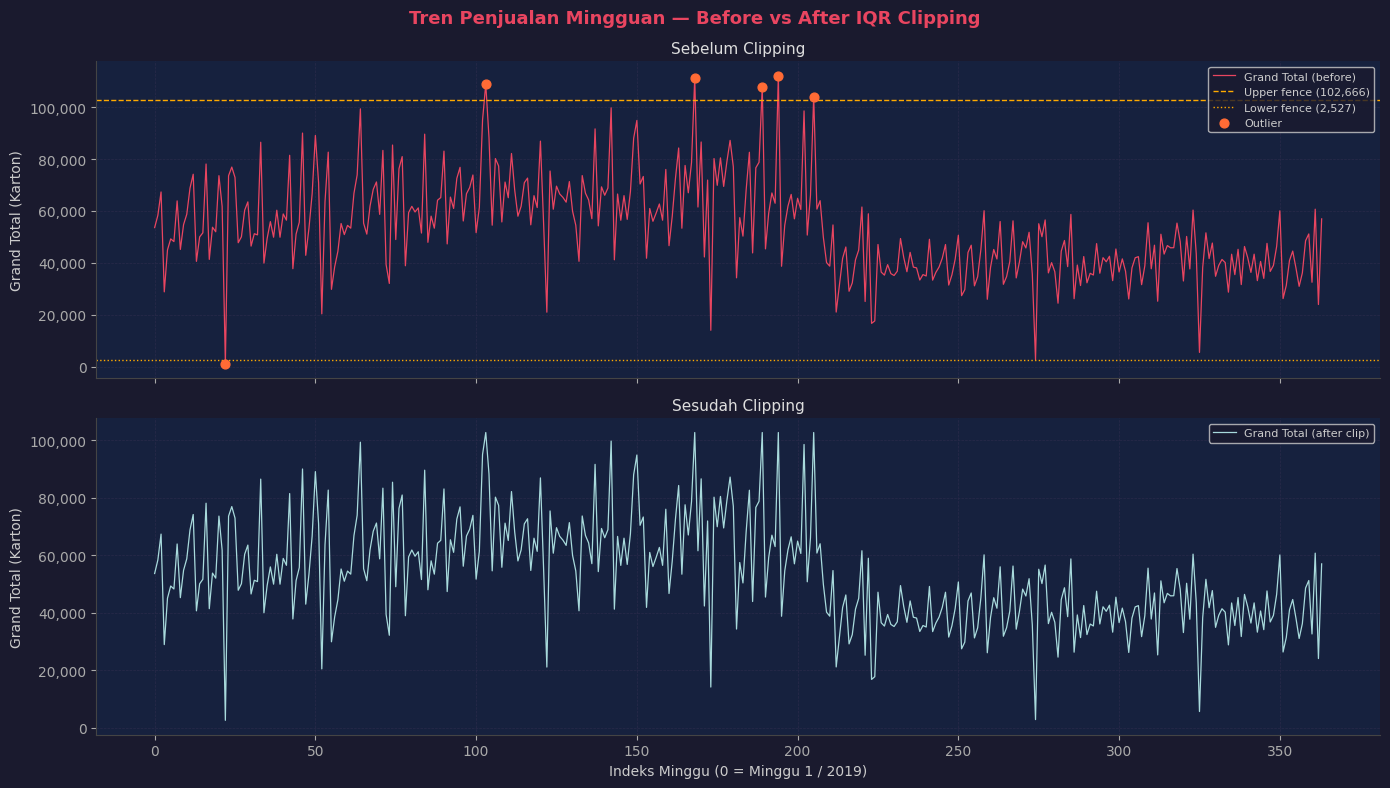

✅ Tersimpan: C:\Users\mikba\Downloads\Semester 7\Pra Tugas Akhir (Retno Aulia Vinarti)\Repository\CNN-BiLSTM-GA-Sales-Forecasting\outputs\figures\nb04_before_after_line.png


In [11]:
# ── Before-After: Line Chart ──────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                         facecolor="#1a1a2e", sharex=True)
fig.suptitle("Tren Penjualan Mingguan — Before vs After IQR Clipping",
             fontsize=13, color="#e94560", fontweight="bold")

idx = np.arange(len(df_sorted))

# ── Before ──────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor("#16213e")
ax.plot(idx, df_sorted["Grand Total"], color="#e94560",
        linewidth=0.9, label="Grand Total (before)")
ax.axhline(upper_fence, color="#ffaa00", linestyle="--",
           linewidth=1, label=f"Upper fence ({upper_fence:,.0f})")
ax.axhline(lower_fence, color="#ffaa00", linestyle=":",
           linewidth=1, label=f"Lower fence ({lower_fence:,.0f})")
# Mark outlier points
ax.scatter(outlier_indices,
           df_sorted.loc[outlier_indices, "Grand Total"],
           color="#ff6b35", zorder=5, s=40, label="Outlier")
ax.set_ylabel("Grand Total (Karton)", color="#ccc")
ax.set_title("Sebelum Clipping", color="#ddd", fontsize=11)
ax.legend(fontsize=8, facecolor="#1a1a2e", labelcolor="#ccc")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(colors="#aaa")
for sp in ax.spines.values(): sp.set_edgecolor("#444")

# ── After ───────────────────────────────────────────────────
ax = axes[1]
ax.set_facecolor("#16213e")
ax.plot(idx, df_clipped["Grand Total"], color="#a8dadc",
        linewidth=0.9, label="Grand Total (after clip)")
ax.set_xlabel("Indeks Minggu (0 = Minggu 1 / 2019)", color="#ccc")
ax.set_ylabel("Grand Total (Karton)", color="#ccc")
ax.set_title("Sesudah Clipping", color="#ddd", fontsize=11)
ax.legend(fontsize=8, facecolor="#1a1a2e", labelcolor="#ccc")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(colors="#aaa")
for sp in ax.spines.values(): sp.set_edgecolor("#444")

plt.tight_layout()

fig_path2 = PATHS["figures"] / "nb04_before_after_line.png"
plt.savefig(fig_path2, dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print(f"✅ Tersimpan: {fig_path2}")

## 💾 6. Simpan Artefak

In [8]:
# ── Simpan outlier_handling.json ─────────────────────────────
outlier_detail = []
for idx in outlier_indices:
    row = df_sorted.loc[idx]
    side  = "above" if row["Grand Total"] > upper_fence else "below"
    clipped_val = float(np.clip(row["Grand Total"], lower_fence, upper_fence))
    outlier_detail.append({
        "index"         : int(idx),
        "year"          : int(row["Year"]),
        "week"          : int(row["Week"]),
        "original_value": int(row["Grand Total"]),
        "clipped_value" : clipped_val,
        "side"          : side,
    })

outlier_summary = {
    "notebook"      : "NB04 — Outlier Handling IQR Clipping",
    "method"        : "IQR Clipping (Winsorization)",
    "q1"            : round(Q1, 4),
    "q3"            : round(Q3, 4),
    "iqr"           : round(IQR, 4),
    "lower_fence"   : round(lower_fence, 4),
    "upper_fence"   : round(upper_fence, 4),
    "n_outliers"    : int(n_outliers),
    "outlier_detail": outlier_detail,
    "stats_before"  : stats_before,
    "stats_after"   : stats_after,
    "figures": {
        "before_after_boxplot_dist": "outputs/figures/nb04_before_after_boxplot_dist.png",
        "before_after_line"        : "outputs/figures/nb04_before_after_line.png",
    }
}

log_path = PATHS["logs"] / "outlier_handling.json"
with open(log_path, "w", encoding="utf-8") as f:
    json.dump(outlier_summary, f, indent=2, ensure_ascii=False)

print(f"✅ Outlier handling tersimpan: {log_path}")
print()
print(json.dumps(outlier_summary, indent=2, ensure_ascii=False))

TypeError: Object of type int64 is not JSON serializable

## ✅ 7. Checklist

In [ ]:
# ── Checklist Akhir Notebook 04 ──────────────────────────────
log_exists     = (PATHS["logs"] / "outlier_handling.json").exists()
fig1_exists    = (PATHS["figures"] / "nb04_before_after_boxplot_dist.png").exists()
fig2_exists    = (PATHS["figures"] / "nb04_before_after_line.png").exists()
no_remaining   = remaining == 0

checklist = [
    ("Batas IQR tercatat (Q1, Q3, IQR, fence)", True),
    ("Jumlah outlier tercatat",                 n_outliers >= 0),
    ("Clipping diterapkan (0 outlier tersisa)", no_remaining),
    ("Perbandingan before-after ada",           fig1_exists and fig2_exists),
    ("Log outlier_handling.json tersimpan",    log_exists),
    ("df_clipped tersedia di memori",           "df_clipped" in dir()),
]

print("=" * 60)
print("  CHECKLIST NOTEBOOK 04")
print("=" * 60)
all_pass = True
for label, status in checklist:
    icon = "✅" if status else "❌"
    if not status:
        all_pass = False
    print(f"  {icon}  {label}")
print("=" * 60)
if all_pass:
    print("  ✅ SEMUA CHECKLIST LULUS — Notebook 04 selesai!")
    print("     Lanjutkan ke Notebook 05 — Sliding Window Supervised Framing.")
else:
    print("  ❌ Ada checklist yang GAGAL — periksa log di atas.")
print("=" * 60)

---

<div style="text-align: center; color: #888; font-size: 0.85em; padding: 12px 0;">

Muhammad Iqbal Baiduri Yamani — NRP 5026221103 · Departemen Sistem Informasi, FTEIC — ITS Surabaya · 2025

</div>

---

| Navigasi | |
|----------|--|
| ◀ Sebelumnya | [NB03 — EDA Univariate Profile](./03%20-%20EDA%20Univariate%20Profile.ipynb) |
| ▶ Berikutnya | [NB05 — Sliding Window Supervised Framing](./05%20-%20Sliding%20Window%20Supervised%20Framing.ipynb) |